In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy.integrate import quad
import seaborn as sns
from scipy import stats


plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.figsize'] = (10, 6)

slope: 1.88, intercept: 5.13


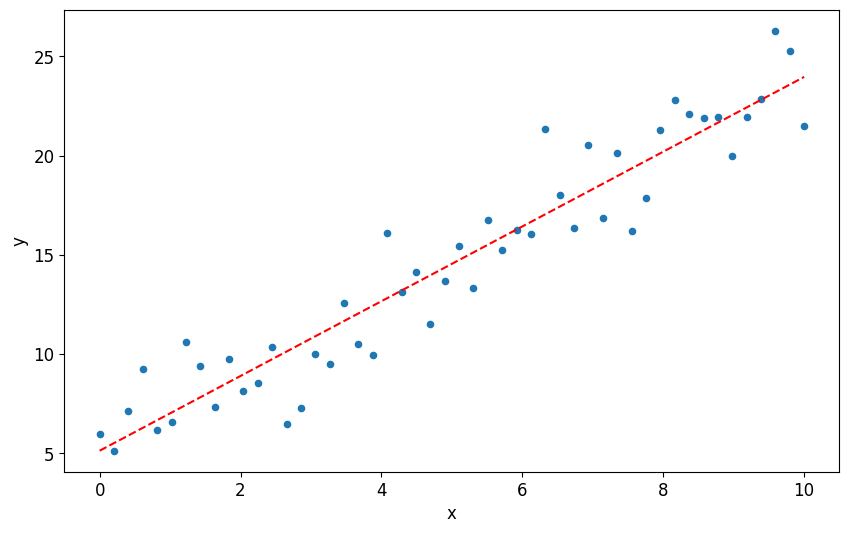

In [2]:
# Ustawienie seed dla powtarzalności
np.random.seed(42)

# Generowanie danych: y ≈ 2x + 5 + szum
n = 50
x = np.linspace(0, 10, n)
y_true = 2 * x + 5  # prawdziwa zależność
noise = np.random.normal(0, 2, n)  # losowy szum
y = y_true + noise

# Stworzenie DataFrame
data = pd.DataFrame({'x': x, 'y': y})


slope, intercept, r_value, p_value, std_err = stats.linregress(data.x, data.y)
print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
fig, ax = plt.subplots()
data.plot(kind="scatter", x='x', y='y', ax=ax)
y_linreg = slope*x + intercept
ax.plot(x, y_linreg, 'r--')

In [3]:
def fit_and_plot(x, y, ax):
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
  print(f"slope: {slope:.2f}, intercept: {intercept:.2f}")
  print(f"r: {r_value}")
  print(f"err: {std_err}")
  ax.plot(x, y, 'bo')
  x_linspace = np.linspace(min(x), max(x), 30)
  y_linreg = slope*x_linspace + intercept
  ax.plot(x_linspace, y_linreg, 'r-')

In [4]:
np.savetxt("dane_do_fit.txt", np.c_[x, y])

In [5]:
df = pd.read_csv("dane_do_fit.txt", delimiter=" ", header=None, names=["x", "y"])

In [6]:
df.head()

,x,y
0,0.000000,5.993428
1,0.204082,5.131635
2,0.408163,7.111704
3,0.612245,9.270550
4,0.816327,6.164346


slope: 1.88, intercept: 5.13
r: 0.9503548762459013
err: 0.08903837899142658


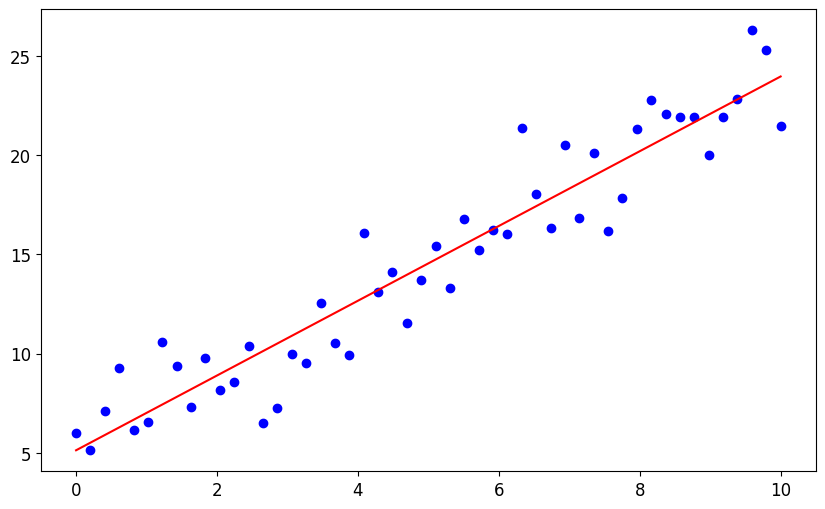

In [7]:
fig, ax = plt.subplots()
fit_and_plot(df['x'], df['y'], ax)

## Zadanie 1

1. **Wczytaj dane:**
   - Wczytaj dane z pliku `anscombe.csv` do DataFrame za pomocą biblioteki `pandas`.
   - Przekształć dane, aby miały format:

     ```
         x1    y1    x2    y2    x3     y3   x4    y4
     0  10.0  8.04  10.0  9.14  10.0   7.46  8.0  6.58
     1   8.0  6.95   8.0  8.14   8.0   6.77  8.0  5.76
     ```

2. **Stwórz wykresy punktowe:**
   - Użyj biblioteki `matplotlib` lub `seaborn`, aby stworzyć wykresy.
   - Na każdej osi (`ax`) umieść wykres punktowy dla par `x1, y1`, `x2, y2`, `x3, y3` oraz `x4, y4`.





In [8]:
! head anscombe.csv

0,0,1,1,2,2,3,3
x,y,x,y,x,y,x,y
10.0,8.04,10.0,9.14,10.0,7.46,8.0,6.58
8.0,6.95,8.0,8.14,8.0,6.77,8.0,5.76
13.0,7.58,13.0,8.74,13.0,12.74,8.0,7.71
9.0,8.81,9.0,8.77,9.0,7.11,8.0,8.84
11.0,8.33,11.0,9.26,11.0,7.81,8.0,8.47
14.0,9.96,14.0,8.10,14.0,8.84,8.0,7.04
6.0,7.24,6.0,6.13,6.0,6.08,8.0,5.25
4.0,4.26,4.0,3.10,4.0,5.39,19.0,12.50


      x1     y1    x2    y2    x3     y3    x4     y4
0   10.0   8.04  10.0  9.14  10.0   7.46   8.0   6.58
1    8.0   6.95   8.0  8.14   8.0   6.77   8.0   5.76
2   13.0   7.58  13.0  8.74  13.0  12.74   8.0   7.71
3    9.0   8.81   9.0  8.77   9.0   7.11   8.0   8.84
4   11.0   8.33  11.0  9.26  11.0   7.81   8.0   8.47
5   14.0   9.96  14.0  8.10  14.0   8.84   8.0   7.04
6    6.0   7.24   6.0  6.13   6.0   6.08   8.0   5.25
7    4.0   4.26   4.0  3.10   4.0   5.39  19.0  12.50
8   12.0  10.84  12.0  9.13  12.0   8.15   8.0   5.56
9    7.0   4.82   7.0  7.26   7.0   6.42   8.0   7.91
10   5.0   5.68   5.0  4.74   5.0   5.73   8.0   6.89


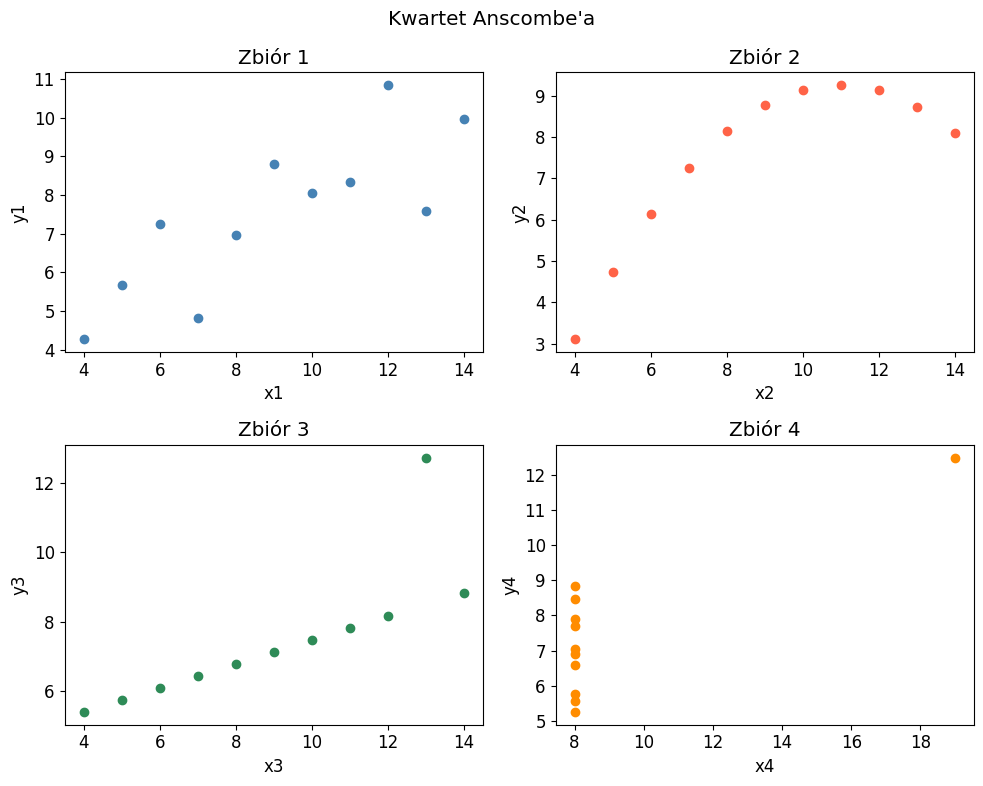

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('anscombe.csv', header=[0, 1])
df.columns = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'x4', 'y4']

print(df)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].scatter(df['x1'], df['y1'], color='steelblue')
axes[0, 0].set_title('Zbiór 1')
axes[0, 0].set_xlabel('x1')
axes[0, 0].set_ylabel('y1')

axes[0, 1].scatter(df['x2'], df['y2'], color='tomato')
axes[0, 1].set_title('Zbiór 2')
axes[0, 1].set_xlabel('x2')
axes[0, 1].set_ylabel('y2')

axes[1, 0].scatter(df['x3'], df['y3'], color='seagreen')
axes[1, 0].set_title('Zbiór 3')
axes[1, 0].set_xlabel('x3')
axes[1, 0].set_ylabel('y3')

axes[1, 1].scatter(df['x4'], df['y4'], color='darkorange')
axes[1, 1].set_title('Zbiór 4')
axes[1, 1].set_xlabel('x4')
axes[1, 1].set_ylabel('y4')

plt.suptitle('Kwartet Anscombe\'a')
plt.tight_layout()
plt.show()

## Zadanie 2

Przeprowadź eksploracyjną analizę danych (EDA) dla zbioru danych o domach `house_train.csv`

Kształt danych: (22687, 22)


,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


,SalePrice,PropertyID,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,SqFtTotLiving,SqFtFinBasement,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode
count,2.268700e+04,2.268700e+04,22687.000000,22687.000000,2.268700e+04,22687.000000,2.268700e+04,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,22687.000000,2.268700e+04,2.268700e+04,22687.000000
mean,5.079244e+05,4.666164e+09,392181.923569,0.901153,5.652333e+05,1.018821,1.174633e+04,2080.165734,293.233305,2.176500,3.367744,7.680963,1971.195266,102.314762,0.205801,2.203211e+05,3.004712e+05,98078.526910
std,3.466368e+05,2.877700e+09,36349.866645,0.083525,3.854029e+05,0.159752,2.901602e+04,913.742170,439.454608,0.768027,0.904379,1.180464,30.313796,440.579006,0.554216,1.829177e+05,2.265750e+05,52.342559
min,3.000000e+03,1.000102e+06,311600.000000,0.715993,3.368000e+03,1.000000,4.940000e+02,370.000000,0.000000,0.000000,0.000000,3.000000,1900.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98001.000000
25%,3.250000e+05,2.212325e+09,360700.000000,0.828814,3.605630e+05,1.000000,4.800000e+03,1420.000000,0.000000,1.750000,3.000000,7.000000,1950.000000,0.000000,0.000000,1.070000e+05,1.720000e+05,98034.000000
50%,4.246500e+05,4.006000e+09,403200.000000,0.926471,4.713150e+05,1.000000,7.200000e+03,1910.000000,0.000000,2.250000,3.000000,7.000000,1977.000000,0.000000,0.000000,1.820000e+05,2.460000e+05,98065.000000
75%,5.850000e+05,7.417700e+09,421200.000000,0.967831,6.494110e+05,1.000000,9.794000e+03,2540.000000,580.000000,2.500000,4.000000,8.000000,2000.000000,0.000000,0.000000,2.670000e+05,3.610000e+05,98117.000000
max,1.100000e+07,9.906000e+09,435200.000000,1.000000,1.164486e+07,5.000000,1.024068e+06,10740.000000,3500.000000,8.000000,33.000000,13.000000,2015.000000,2016.000000,3.000000,5.538000e+06,5.772000e+06,98354.000000


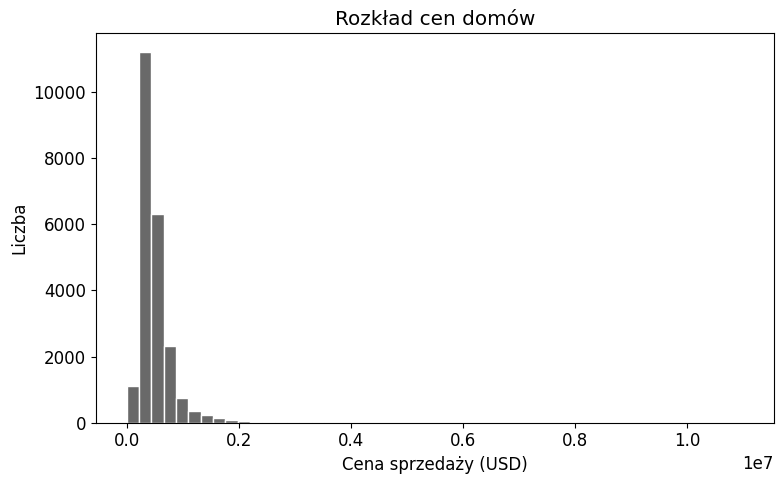

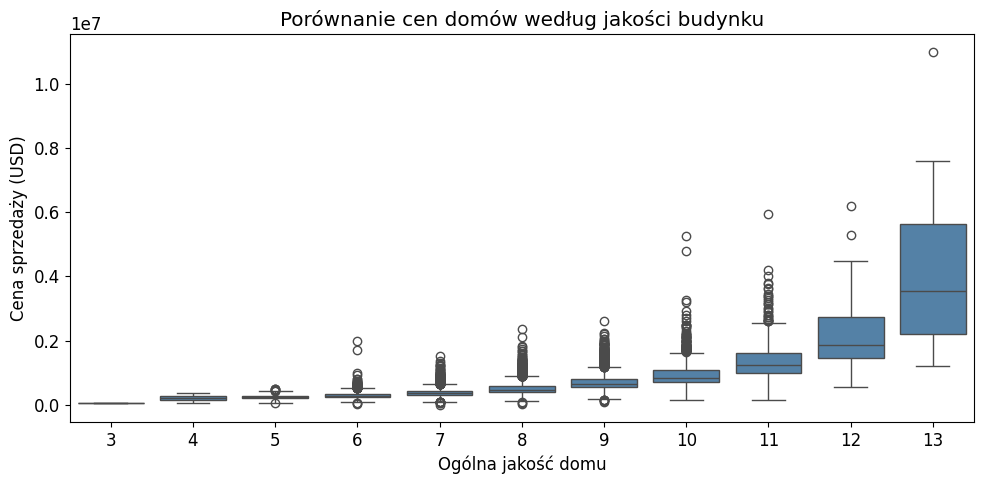

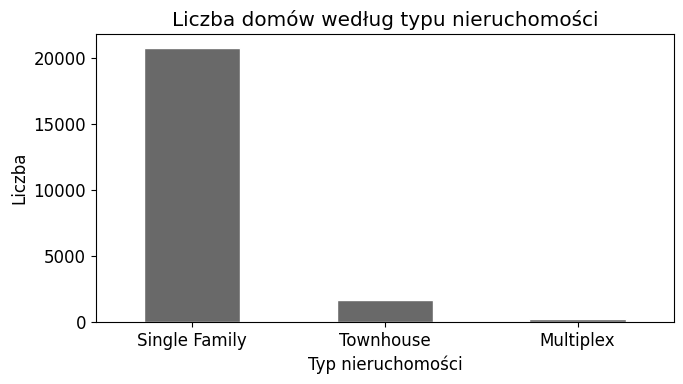

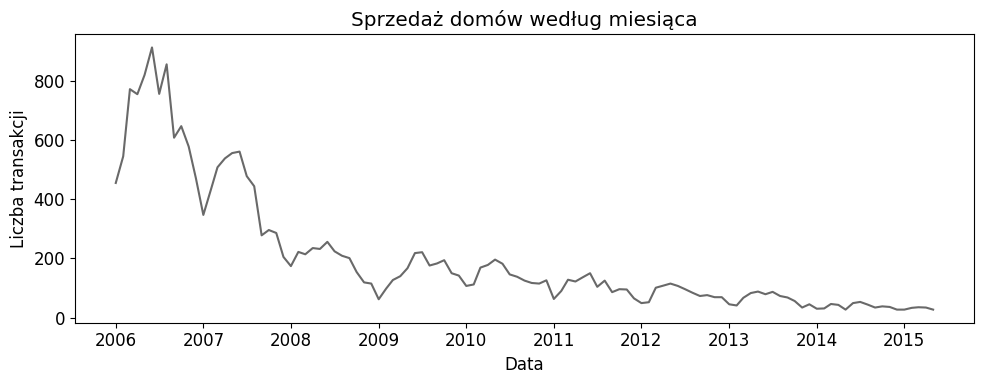

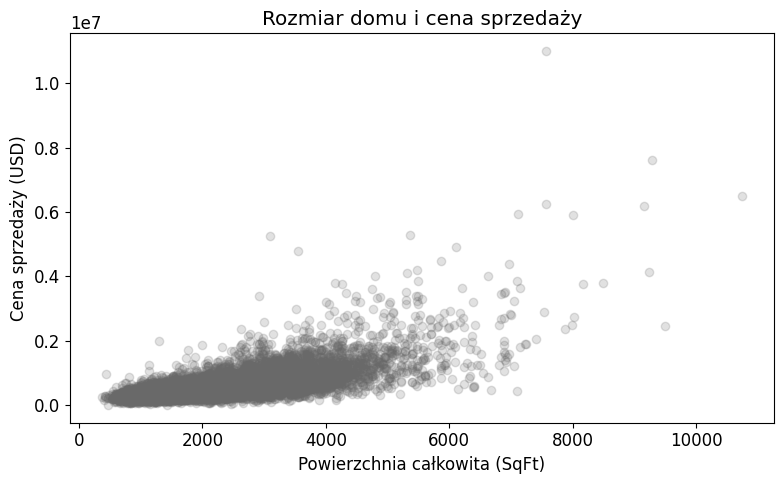

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('house_sales.csv', sep='\t')

print("Kształt danych:", df.shape)
display(df.head())
display(df.describe())

# 1. Histogram rozkładu cen (slajd: "Rozkład cen domów")
plt.figure(figsize=(8, 5))
plt.hist(df['SalePrice'], bins=50, color='dimgray', edgecolor='white')
plt.title('Rozkład cen domów')
plt.xlabel('Cena sprzedaży (USD)')
plt.ylabel('Liczba')
plt.tight_layout()
plt.show()

# 2. Boxplot cena vs jakość budynku (slajd: "Wykres skrzynkowy")
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='BldgGrade', y='SalePrice', color='steelblue')
plt.title('Porównanie cen domów według jakości budynku')
plt.xlabel('Ogólna jakość domu')
plt.ylabel('Cena sprzedaży (USD)')
plt.tight_layout()
plt.show()

# 3. Wykres słupkowy - typy nieruchomości (slajd: "Wykres słupkowy")
plt.figure(figsize=(7, 4))
df['PropertyType'].value_counts().plot(kind='bar', color='dimgray', edgecolor='white')
plt.title('Liczba domów według typu nieruchomości')
plt.xlabel('Typ nieruchomości')
plt.ylabel('Liczba')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Wykres liniowy - sprzedaż według miesięcy (slajd: "Wykres liniowy")
df['DocumentDate'] = pd.to_datetime(df['DocumentDate'])
sprzedaz_miesiecznie = df.groupby(df['DocumentDate'].dt.to_period('M')).size()
sprzedaz_miesiecznie.index = sprzedaz_miesiecznie.index.to_timestamp()

plt.figure(figsize=(10, 4))
plt.plot(sprzedaz_miesiecznie.index, sprzedaz_miesiecznie.values, color='dimgray')
plt.title('Sprzedaż domów według miesiąca')
plt.xlabel('Data')
plt.ylabel('Liczba transakcji')
plt.tight_layout()
plt.show()

# 5. Wykres punktowy - powierzchnia vs cena (slajd: "Wykres punktowy")
plt.figure(figsize=(8, 5))
plt.scatter(df['SqFtTotLiving'], df['SalePrice'], alpha=0.2, color='dimgray')
plt.title('Rozmiar domu i cena sprzedaży')
plt.xlabel('Powierzchnia całkowita (SqFt)')
plt.ylabel('Cena sprzedaży (USD)')
plt.tight_layout()
plt.show()